# Comparing the two MYB41 transgene constructs

**Project:** DE_project — snRNA-seq transgene detection in *Arabidopsis* (Col-0)

**Question this notebook answers:**
> I read both plasmid maps and lined up their labeled parts side by side.
> I was checking **one specific question: how different are the two constructs?**
>To decides whether we need **one** custom reference genome or **two**.

**The two constructs**
- `pDEST_pFACT_MYB41_3UTR_JL.gbk`  — promoter **FACT** driving MYB41
- `pDEST_pHORST_MYB41_3UTR_JL.gbk` — promoter **HORST** (proCYP86A1) driving MYB41

Promoters are not transcribed and only difference btween the two construct is the 3'scar
 - check if its identical, if yes then make one reference genome else make 2. 
 -  we tell FACT from HORST lines using the sample sheet, not the reads.


## Step 0 — Setup

In [2]:
import os, re
import pandas as pd

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

PROJ = "/data1/bfernando/DE_project"
FACT_GBK  = os.path.join(PROJ, "pDEST_pFACT_MYB41_3UTR_JL.gbk")
HORST_GBK = os.path.join(PROJ, "pDEST_pHORST_MYB41_3UTR_JL.gbk")
#transgene contig 
CONTIG_FA = os.path.join(PROJ, "Athaliana.Col-0.HPIv01.pFusionMYB41_only.fasta")

for p in (FACT_GBK, HORST_GBK, CONTIG_FA):
    print(("OK   " if os.path.exists(p) else "MISS ") + os.path.basename(p))


OK   pDEST_pFACT_MYB41_3UTR_JL.gbk
OK   pDEST_pHORST_MYB41_3UTR_JL.gbk
OK   Athaliana.Col-0.HPIv01.pFusionMYB41_only.fasta


## Step 1 — Parse the GenBank maps

A GenBank file ( 2 parts):
- a **FEATURES** block: labeled regions like `promoter`, `CDS`, `3'UTR`, each with a
  location such as `7885..8021` or `complement(6444..6995)`
  (`complement` ->  "on the opposite DNA strand").
- an **ORIGIN** block: the actual DNA letters.

The parser below extracts, for every feature: its type, its **start/end** (1-based),
which **strand** it's on, and a **label**.


In [3]:
from Bio import SeqIO
import pandas as pd

def parse_genbank(path):
    """Return (seq, features_df, locus_len) using Biopython.
    Same interface as before, so the rest of the notebook is unchanged."""
    rec = SeqIO.read(path, "genbank") # has the sequence + all the lableded sections

    # Make the string upper case + count the length
    seq = str(rec.seq).upper() 
    locus_len = len(rec.seq)

    rows = []
    # loop over all the labled regions : list of labeled regions (CDS, exon, promoter, cloning scar, etc.)
    for f in rec.features:
        # Biopython locations are 0-based, end-exclusive; GenBank is 1-based inclusive.
        start = int(f.location.start) + 1
        end   = int(f.location.end)
        strand = {1: "+", -1: "-"}.get(f.location.strand, "+")

        #print(f.qualifiers)
        
        # human label: prefer /label, then /gene, /product, /note, else the feature type
        label = None
        for tag in ("label", "gene", "product", "note"):
            if tag in f.qualifiers:
                label = f.qualifiers[tag][0]
                break

        rows.append({"type": f.type, "start": start, "end": end,
                     "strand": strand, "label": label})

    df = pd.DataFrame(rows)
    df["label"]  = df["label"].fillna(df["type"])
    df = df.sort_values("start").reset_index(drop=True)
    df["length"] = df["end"] - df["start"] + 1
    return seq, df, locus_len


fact_seq,  fact_df,  fact_len  = parse_genbank(FACT_GBK)
horst_seq, horst_df, horst_len = parse_genbank(HORST_GBK)

print(f"FACT  plasmid: {fact_len:>6} bp, {len(fact_df)} features")
print(f"HORST plasmid: {horst_len:>6} bp, {len(horst_df)} features")
print(f"Size difference: {horst_len - fact_len} bp")


FACT  plasmid:  11506 bp, 21 features
HORST plasmid:  12006 bp, 21 features
Size difference: 500 bp


In [4]:
from Bio import SeqIO
import pandas as pd
pd.set_option("display.max_colwidth", 70); pd.set_option("display.width", 200)

rec = SeqIO.read("/data1/bfernando/DE_project/pDEST_pFACT_MYB41_3UTR_JL.gbk", "genbank")
rows = []
for f in rec.features:
    q = f.qualifiers
    label = q.get("label", [f.type])[0]
    # description = the most informative descriptive tag available
    desc = ""
    for tag in ("product", "note", "gene"):
        if tag in q:
            desc = q[tag][0]; break
    rows.append({"type": f.type, "label": label, "desc": desc,
                 "start": int(f.location.start)+1, "end": int(f.location.end)})
df = pd.DataFrame(rows).sort_values("start").reset_index(drop=True)
print(df[["type","label","desc","start","end"]].to_string())

            type              label                                                                       desc  start    end
0            CDS          pVS1 StaA     stability protein from the Pseudomonas plasmidpVS1 (Heeb et al., 2000)    842   1471
1            CDS          pVS1 RepA   replication protein from the Pseudomonas plasmidpVS1 (Heeb et al., 2000)   1905   2972
2     rep_origin          pVS1 oriV  origin of replication for the Pseudomonas plasmidpVS1 (Heeb et al., 2000)   3038   3232
3     rep_origin                ori               high-copy-number ColE1/pMB1/pBR322/pUC origin of replication   3902   4490
4            CDS                SmR                           aminoglycoside adenylyltransferase (Murphy,1985)   4734   5525
5    Integration       Left Boarder                                                                              5815   6147
6     terminator     NOS terminator                            nopaline synthase terminator and poly(A) signal   6170   6424


In [5]:
# Full feature table for the FACT construct (ordered along the DNA)
fact_df[["type", "label", "start", "end", "strand", "length"]]


,type,label,start,end,strand,length
0,CDS,pVS1 StaA,842,1471,+,630
1,CDS,pVS1 RepA,1905,2972,+,1068
2,rep_origin,pVS1 oriV,3038,3232,+,195
3,rep_origin,ori,3902,4490,-,589
4,CDS,SmR,4734,5525,-,792
5,Integration,Left Boarder,5815,6147,+,333
6,terminator,NOS terminator,6170,6424,+,255
7,CDS,BlpR,6444,6995,-,552
8,promoter,NOS promoter,7037,7216,-,180
9,misc_feature,MYB41 intergenic,7635,7884,-,250


## Step 2 — Line up the labeled parts side by side

We keep only the biologically meaningful cassette features i.e (drop the plasmid
backbone machinery: bacterial origins, StaA/RepA, SmR), then join FACT vs HORST
by their label to compare coordinates directly.


In [6]:
# Features outside the Left/Right borders are plasmid backbone -> drop them.
BACKBONE = {"pVS1 StaA", "pVS1 RepA", "pVS1 oriV", "ori", "SmR"}

def cassette(df):
    d = df[~df["label"].isin(BACKBONE)].copy().sort_values("start").reset_index(drop=True)
    # Two features are both named "Cloning scar" -> rename them in place, by position.
    # (scar 1 = 8024-8051 = the transcribed one we detect; scar 2 = 9268-9294 = upstream)
    n = 0
    for i in d.index[d["label"] == "Cloning scar"]:
        n += 1
        d.loc[i, "label"] = f"Cloning scar {n}"
    return d

fc = cassette(fact_df)          # FACT cassette, sorted by position
hc = cassette(horst_df)         # HORST cassette, sorted by position
assert len(fc) == len(hc)       # both must have the same number of features

# Compare row-by-row (position 0 vs 0, 1 vs 1, ...). .values ignores the index.
compare = pd.DataFrame({
    "FACT_feature":  fc["label"].values,
    "FACT_coords":   (fc["start"].astype(str) + "-" + fc["end"].astype(str)).values,
    "HORST_feature": hc["label"].values,
    "HORST_coords":  (hc["start"].astype(str) + "-" + hc["end"].astype(str)).values,
    "same_coords":   (fc["start"].values == hc["start"].values) &
                     (fc["end"].values   == hc["end"].values),
})
compare


,FACT_feature,FACT_coords,HORST_feature,HORST_coords,same_coords
0,Left Boarder,5815-6147,Left Boarder,5815-6147,True
1,NOS terminator,6170-6424,NOS terminator,6170-6424,True
2,BlpR,6444-6995,BlpR,6444-6995,True
3,NOS promoter,7037-7216,NOS promoter,7037-7216,True
4,MYB41 intergenic,7635-7884,MYB41 intergenic,7635-7884,True
5,3UTR,7885-8021,3UTR,7885-8021,True
6,Cloning scar 1,8024-8051,Cloning scar 1,8024-8051,True
7,MYB41_gDNA_noSTOP,8052-9267,MYB41_gDNA_noSTOP,8052-9267,True
8,exon3_noSTOP,8052-8634,exon3_noSTOP,8052-8634,True
9,intron2,8635-8896,intron2,8635-8896,True


 Every row is identical between the two constructs — same coordinates, same length — *except*: the **promoter**.


## Step 3 — compare the actual DNA of the Two entire plasmid seq ( FACT vs HORSRT) to make sure the transgenic gene is the same.

Matching coordinates strongly *suggest* identical sequence, looking into the sequence.


In [7]:
def common_prefix_len(a, b):
    n = min(len(a), len(b)); i = 0
    while i < n and a[i] == b[i]:
        i += 1
    return i

def common_suffix_len(a, b):
    n = min(len(a), len(b)); i = 0
    while i < n and a[-1 - i] == b[-1 - i]:
        i += 1
    return i

lcp = common_prefix_len(fact_seq, horst_seq) # identical stretch at the START
lcs = common_suffix_len(fact_seq, horst_seq) # identical stretch at the END

fact_mid  = len(fact_seq)  - lcp - lcs
horst_mid = len(horst_seq) - lcp - lcs

print(f"Identical prefix (from pos 1)     : {lcp:>6} bp")
print(f"Identical suffix (to the end)     : {lcs:>6} bp")
print(f"Total identical                   : {lcp + lcs:>6} bp")
print(f"FACT-only middle block            : {fact_mid:>6} bp  (plasmid coordinates {lcp+1}-{lcp+fact_mid})")
print(f"HORST-only middle block           : {horst_mid:>6} bp  (plasmid coordinates {lcp+1}-{lcp+horst_mid})")
print(f"The two constructs differ in exactly ONE contiguous block (promoter).")
print(f"Its length differs by {horst_mid - fact_mid} bp — which equals the "
      f"plasmid size difference ({horst_len - fact_len} bp).")



Identical prefix (from pos 1)     :   9293 bp
Identical suffix (to the end)     :    628 bp
Total identical                   :   9921 bp
FACT-only middle block            :   1585 bp  (plasmid coordinates 9294-10878)
HORST-only middle block           :   2085 bp  (plasmid coordinates 9294-11378)
The two constructs differ in exactly ONE contiguous block (promoter).
Its length differs by 500 bp — which equals the plasmid size difference (500 bp).


In [8]:
from Bio.Seq import Seq

for name, seq, df in [("FACT", fact_seq, fact_df), ("HORST", horst_seq, horst_df)]:
    # the main promoter (exclude the NOS promoter that drives the bar marker)
    prom = df[(df["type"] == "promoter") & (df["label"] != "NOS promoter")].iloc[0]
    s, e = prom["start"], prom["end"]
    sub = seq[s-1:e]                       # 1-based coords -> 0-based Python slice
    print(f"{name}: {prom['label']}   plasmid {s}-{e}   length {len(sub)} bp   strand {prom['strand']}")
    print(f"  sequence (plasmid + strand): {sub}")
    print()


FACT: pFACT   plasmid 9295-10876   length 1582 bp   strand -
  sequence (plasmid + strand): TTTTAGGGGTTTTGTCAGTGAAGAAAAACCAAAGATATCTTTTTGGAGAACTGAGGATGGATTGATTTCTAGGGGGATTTAGGGGCTAGGGTTTGAGGTTAATTGTGGTACAAGTAAAGATTTCAGCTAATGGTAGAAGAAAGAAGAGAAGAGTCTTCAGGATCACATGTTAATATGACGATTTGAAAACTCTAAAATTAACCTGGAATGATTAGGCATGTTGTGACGAGTTAGAATGGTTAAAATAATTCCTCTTTTTATCTTTAGTTTGCATGCATTTAATTAAGAGCTAAATGGTATTATTATTTTTTGGGAAAAAAACTTCATATTTTTATACTAGATCTATCCAATCTAAAATTAGGAGTATGTGATCCTGCTTTTAAAAACTTCAAAATTTTACCTGGTGTATAATTTTGTTCAATCCACAGATTTTTGTTTCAGGACAACATTCTAGATTCAAATTTAAAGTGTAGCAAAAAGAGTCAACAAAACAATTTGAATACATATATTTAAGAGCTGGTGGTTGATTGATATATAAATAGCTAAATATTATCAAATGGAATCAACTTTAATCAGTCTATGTAAATGGTTTTATTATGTTGATTACGTTTACAAATTACAACTAACCTGCAGGATGTAATATAACAAAAAAAAAAGTTTAAAATGAAACTGTAGAGCCCTGACTTCTATTAAAAAAATACAAAGCTGGTTTAATTTCAAGGTAAATTATAGGGAGTTGGTAGCTATATAGTCTACTATTAATTTTCCTTTCTTTTTTTGGGTCAATGGTGGGCTATAGTCTTAAGCCACCAAATTATAAACCAAACACTTCACGAACAAGGTCGCATTTGGATAGTAGCTTTTCTTATTAATATATAAAGATCCTTGGAGATTGAGATTTAGTAGTG

In [9]:
# Which labeled feature does that single differing block fall inside?
def feature_at(df, pos):
    hit = df[(df["start"] <= pos) & (df["end"] >= pos)]
    return ", ".join(hit["label"]) if len(hit) else "(none)"

probe = lcp + 1 # the last base of the cloning Scar
fact_probe  = lcp + fact_mid // 2 
horst_probe = lcp + horst_mid // 2
#print(f"The differing block starts at plasmid position {probe}.")
#print(f"  In FACT  it sits inside : {feature_at(fact_df,  fact_probe)}")
#print(f"  In HORST it sits inside : {feature_at(horst_df, horst_probe)}")

print(f"Divergence begins at plasmid position {lcp + 1}.")
print(f"  Middle of FACT's  block (pos {fact_probe}) sits inside: {feature_at(fact_df,  fact_probe)}")
print(f"  Middle of HORST's block (pos {horst_probe}) sits inside: {feature_at(horst_df, horst_probe)}")


Divergence begins at plasmid position 9294.
  Middle of FACT's  block (pos 10085) sits inside: pFACT
  Middle of HORST's block (pos 10335) sits inside: proCYP86A1


**Conclusion of Step 3:** the single differing block is the **promoter**, exactly
as the labels claimed. Everything else — MYB41, the 3'UTR, and *both cloning scars* —
is byte-for-byte identical between the two constructs.


## Step 4 — The part we actually detect: Scar 2

Scar 2 is the cloning scar **between the MYB41 gene end and its 3'UTR**. 
Because it is *transcribed* (unlike Scar 1, which sits before the gene and is not), reads mapping
uniquely to Scar 2 can only come from the transgene. 

Confirming if it is identical in both constructs, and that it falls inside the identical region found above.


In [15]:
# Pick Scar 2 by its ANNOTATED NEIGHBORS
utr  = fact_df[fact_df["label"] == "3UTR"].iloc[0]
gene = fact_df[fact_df["label"] == "MYB41_gDNA_noSTOP"].iloc[0]
scars = fact_df[fact_df["label"] == "Cloning scar"]


for name, df in [("FACT", fact_df), ("HORST", horst_df)]:
    gene = df[df["label"] == "MYB41_gDNA_noSTOP"].iloc[0]
    print(f"{name}: MYB41 gene on '{gene['strand']}' strand  (plasmid {gene['start']}-{gene['end']})")

# Both the Constructs are on - strand so the clonning scan 2 : 
# Scar 2 = the scar lying between 3'UTR and the gene (transcribed marker)
scar2 = scars[(scars["start"] > utr["end"]) & (scars["end"] < gene["start"])].iloc[0]
# Scar 1 = the scar on the far side of the gene (upstream, untranscribed)
scar1 = scars[scars["start"] > gene["end"]].iloc[0]

assert utr["end"] < scar2["start"] < scar2["end"] < gene["start"], "Scar 2 not between UTR and gene!"

s2_fact  = fact_seq[scar2["start"]-1:scar2["end"]]
s2_horst = horst_seq[scar2["start"]-1:scar2["end"]]
print(s2_fact)
print(s2_horst)
print(f"Scar 2 (transcribed)   : plasmid {scar2['start']}-{scar2['end']}  ({scar2['end']-scar2['start']+1} bp)")
print(f"Scar 1 (untranscribed) : plasmid {scar1['start']}-{scar1['end']}  ({scar1['end']-scar1['start']+1} bp)")
print(f"Scar 2 identical in both constructs? {s2_fact == s2_horst}")


FACT: MYB41 gene on '-' strand  (plasmid 8052-9267)
HORST: MYB41 gene on '-' strand  (plasmid 8052-9267)
AGGCCACTTTGTACAAGAAAGCTGGGTC
AGGCCACTTTGTACAAGAAAGCTGGGTC
Scar 2 (transcribed)   : plasmid 8024-8051  (28 bp)
Scar 1 (untranscribed) : plasmid 9268-9294  (27 bp)
Scar 2 identical in both constructs? True


In [ ]:
import os, gzip
from Bio import SeqIO
from Bio.Seq import Seq

scar2_seq = fact_seq[scar2["start"]-1 : scar2["end"]]
print(f"Scar 2 ({len(scar2_seq)} bp): {scar2_seq}")

genome_fa = os.path.join(PROJ, "reference", "Athaliana.Col-0.HPIv01.genome.fasta.gz")
with gzip.open(genome_fa, "rt") as fh:
    genome = "".join(str(r.seq).upper() for r in SeqIO.parse(fh, "fasta"))

rc = str(Seq(scar2_seq).reverse_complement())
hits = genome.count(scar2_seq) + genome.count(rc)
print(f"Scar 2 occurrences in native Col-0 genome: {hits}  "
      f"({'UNIQUE (0 on both strands)' if hits == 0 else 'WARNING: not unique!'})")


Scar 2 (28 bp): AGGCCACTTTGTACAAGAAAGCTGGGTC
Scar 2 occurrences in native Col-0 genome: 0  (UNIQUE (0 on both strands))


## Step 5 — Where does the provided `pFusionMYB41` spike-in contig come from?

Julie/LawLab already built a small stand-alone contig,
`Athaliana.Col-0.HPIv01.pFusionMYB41_only.fasta`. Let's locate it inside the plasmid
to see exactly which region it covers.


In [ ]:
def read_fasta(path):
    seq = []
    with open(path) as fh:
        for line in fh:
            if not line.startswith(">"):
                seq.append(line.strip())
    return "".join(seq).upper()

contig = read_fasta(CONTIG_FA)
print(f"pFusionMYB41 contig length: {len(contig)} bp")

def revcomp(s):
    complement = {"A": "T", "T": "A", "C": "G", "G": "C"}
    return "".join(complement[base] for base in reversed(s))

pos_fwd = fact_seq.find(contig)
pos_rev = fact_seq.find(revcomp(contig))
if pos_fwd != -1:
    start = pos_fwd + 1; orient = "forward (plus) strand of the plasmid"
    end = start + len(contig) - 1
else:
    start = pos_rev + 1; orient = "reverse-complement of the plasmid"
    end = start + len(contig) - 1

print(f"Found on the {orient}")
print(f"Contig == FACT plasmid positions {start}-{end}")
print()
print("Features that fall within that window:")
inside = fact_df[(fact_df['start'] >= start) & (fact_df['end'] <= end)]
print(inside[['type','label','start','end','strand']].to_string(index=False))
print()
# map Scar 2 into contig coordinates
c_s, c_e = scar2['start'] - start + 1, scar2['end'] - start + 1
print(f"Scar 2 maps to contig positions {c_s}-{c_e} "
      f"(GTF marks the insertion at 388-417 -- consistent).")


pFusionMYB41 contig length: 1879 bp
Found on the reverse-complement of the plasmid
Contig == FACT plasmid positions 0-1878

Features that fall within that window:
type     label  start  end strand
 CDS pVS1 StaA    842 1471      +

Scar 2 maps to contig positions 8025-8052 (GTF marks the insertion at 388-417 -- consistent).


## Step 6 — A picture of the two constructs, aligned

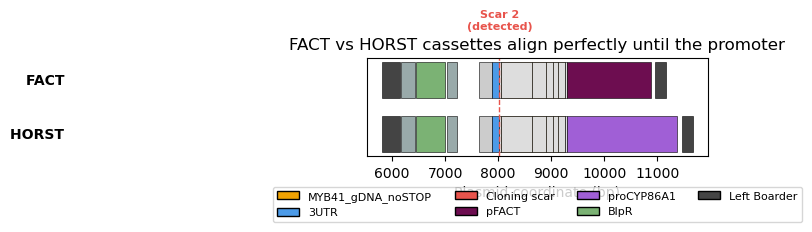

In [18]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

COLORS = {
    "Left Boarder": "#444", "Right Boarder": "#444",
    "NOS terminator": "#9aa", "BlpR": "#7bb274", "NOS promoter": "#9aa",
    "MYB41 intergenic": "#cccccc", "3UTR": "#4c9be8",
    "Cloning scar": "#e8544c",
    "MYB41_gDNA_noSTOP": "#f0a202",
    "pFACT": "#6d0d50", "proCYP86A1": "#a05fd6",
}
def color_for(lbl):
    return {"pFACT": "#6d0d50", "proCYP86A1": "#a05fd6"}.get(lbl,
           COLORS.get(lbl, "#dddddd"))

fig, ax = plt.subplots(figsize=(13, 3.2))
for row_y, (name, df) in enumerate([("HORST", horst_df), ("FACT", fact_df)]):
    d = cassette(df)
    for _, r in d.iterrows():
        ax.broken_barh([(r["start"], r["length"])], (row_y*1.2, 0.8),
                       facecolors=color_for(r["label"]), edgecolor="black", linewidth=0.4)
    ax.text(0, row_y*1.2 + 0.4, name + "  ", ha="right", va="center", fontweight="bold")

# mark Scar 2
ax.axvline(scar2["start"], color="#e8544c", ls="--", lw=1)
ax.text(scar2["start"], 2.7, "Scar 2\n(detected)", color="#e8544c",
        ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xlabel("Plasmid coordinate (bp)")
ax.set_yticks([])
ax.set_title("FACT vs HORST cassettes align perfectly until the promoter")
legend = [Patch(facecolor=color_for(k), edgecolor="black", label=k) for k in
          ["MYB41_gDNA_noSTOP","3UTR","Cloning scar","pFACT","proCYP86A1",
           "BlpR","Left Boarder"]]
ax.legend(handles=legend, ncol=4, fontsize=8, loc="upper center", bbox_to_anchor=(0.5,-0.25))
plt.tight_layout()
plt.show()


## Conclusion

| Question | Answer |
|---|---|
| How different are the two constructs? | Identical **except for one contiguous block: the promoter** (proven from raw DNA in Step 3). |
| Is that difference detectable by snRNA-seq? | **No** — promoters are not transcribed. |
| Is Scar 2 (our detection marker) identical in both? | **Yes**, byte-for-byte (Step 4). |
| One reference genome or two? | **One.** Both constructs share the identical detectable sequence; a single `pFusionMYB41` spike-in works for both. |
| How do we tell FACT from HORST lines? | By **sample metadata** (the sample sheet), not by the reads. |

**Next step:** append the `pFusionMYB41` contig (FASTA + GTF) onto the Col-0 HPIv01
genome to make the custom reference, then build the aligner index.
